<a href="https://colab.research.google.com/github/ridahafeez786/AI_Bootcamp_Lab-work/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Clustering

## 1. Load Data from Kaggle

https://www.kaggle.com/datasets/sagarchhabriya/clustering

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sagarchhabriya/clustering")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'clustering' dataset.
Path to dataset files: /kaggle/input/clustering


### List the path

In [2]:
import os

os.listdir(path)

['student_clustering.csv']

### display df

In [3]:
import pandas as pd

df = pd.read_csv(path + "/student_clustering.csv")
df

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110
...,...,...
195,4.68,89
196,8.57,118
197,5.85,112
198,6.23,108


In [4]:
# about dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   cgpa    200 non-null    float64
 1   iq      200 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.3 KB


In [5]:
# check missing

df.isna().sum()

,0
cgpa,0
iq,0


In [6]:
# check for duplicates

df.duplicated().sum()

np.int64(7)

### scatter plot of cgpa and iq

In [7]:
# import libraries

import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='cgpa', ylabel='iq'>

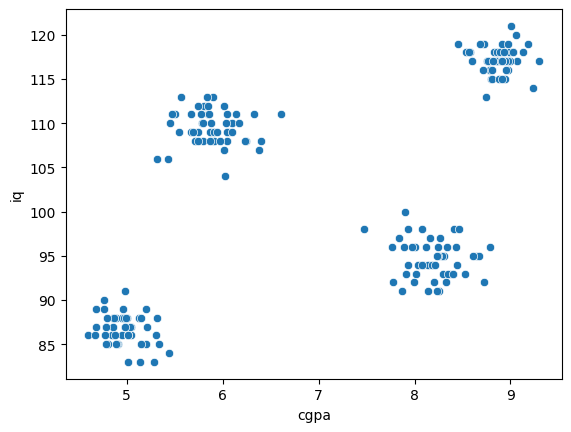

In [8]:
# scatter plot

sns.scatterplot(data=df, x='cgpa', y='iq')

## Import KMeans from sklearn.cluster and train the model

In [9]:
# import

from sklearn.cluster import KMeans

In [10]:
#  training the model, predicting, and inspecting intertia


km = KMeans(n_clusters=3)

km.fit_predict(df)

array([1, 0, 1, 1, 0, 0, 1, 2, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 0, 2, 0, 2, 0, 1, 1, 2, 0, 1, 0, 1, 1, 1, 1,
       2, 2, 1, 0, 2, 0, 1, 1, 2, 1, 2, 0, 0, 2, 0, 2, 0, 1, 1, 2, 1, 2,
       1, 1, 0, 1, 0, 2, 1, 1, 0, 2, 0, 2, 1, 1, 1, 2, 0, 1, 2, 1, 2, 0,
       2, 0, 2, 2, 1, 1, 1, 1, 2, 1, 1, 2, 0, 1, 1, 2, 1, 1, 1, 1, 2, 2,
       1, 2, 0, 0, 1, 2, 1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 2, 0, 1, 1, 1, 1, 1, 0, 1, 1, 2, 1, 2, 0, 1, 2, 1, 2, 2,
       1, 1, 0, 2, 0, 1, 1, 2, 0, 1, 2, 1, 0, 1, 1, 2, 2, 0, 2, 1, 1, 1,
       2, 0, 1, 2, 2, 0, 0, 0, 1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 1, 2, 0,
       0, 2], dtype=int32)

In [11]:
# print intertia (wcss)

km.inertia_

2503.3975810000015

In [12]:
# Iterate the process from k = 1 to 10
# train the model and calculating WCSS (i.e., intertia)
# k = 1, 2, ... 10

wcss = []

for k in range(1, 11):
  km = KMeans(n_clusters=k)
  km.fit_predict(df)
  wcss.append(km.inertia_)

### Print the WCSS List

In [13]:
wcss

[29957.898287999997,
 4184.141269999999,
 2503.3975810000015,
 681.9696600000001,
 523.7131894763968,
 446.7996165765536,
 376.82998415554687,
 313.11847565652096,
 243.9352847931496,
 176.56993298346399]

### Plot the Elbow Curve
  - x = range(a, b)
  - y = wcss
  - plt.plot(x, y)

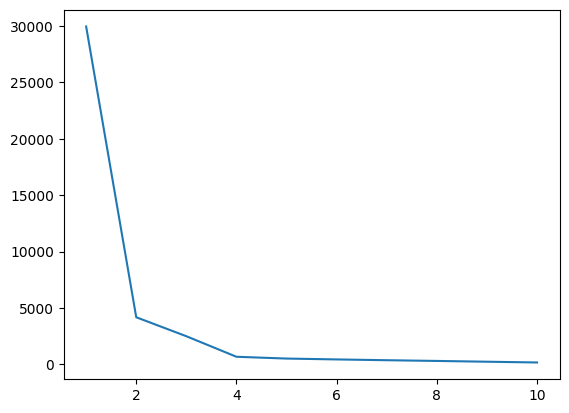

In [14]:
x = range(1,11)
y = wcss

plt.plot(x, y)

### Retrain the KMeans with Best K

In [15]:
# convert pd to numpy

X = df.iloc[:, :].values

km = KMeans(n_clusters=4)

y_means = km.fit_predict(X)

In [16]:
# print y_means
y_means

array([0, 3, 2, 2, 3, 3, 2, 1, 3, 2, 0, 3, 2, 0, 3, 2, 3, 2, 3, 3, 2, 0,
       2, 0, 0, 2, 0, 1, 2, 3, 1, 3, 1, 3, 2, 2, 1, 3, 0, 3, 0, 2, 2, 0,
       1, 1, 2, 3, 1, 3, 0, 0, 1, 2, 1, 3, 3, 1, 3, 1, 3, 2, 2, 1, 0, 1,
       2, 0, 3, 2, 3, 1, 2, 0, 3, 1, 3, 1, 0, 2, 2, 1, 3, 0, 1, 0, 1, 3,
       1, 3, 1, 1, 2, 0, 2, 2, 1, 2, 0, 1, 3, 0, 0, 1, 0, 0, 2, 0, 1, 1,
       2, 1, 3, 3, 2, 1, 2, 3, 1, 0, 0, 3, 2, 1, 2, 0, 2, 3, 0, 2, 2, 3,
       0, 0, 3, 1, 3, 0, 2, 2, 2, 0, 3, 0, 0, 1, 0, 1, 3, 0, 1, 0, 1, 1,
       0, 2, 3, 1, 3, 2, 0, 1, 3, 2, 1, 0, 3, 0, 0, 1, 1, 3, 1, 0, 0, 2,
       1, 3, 0, 1, 1, 3, 3, 3, 2, 0, 2, 2, 1, 3, 2, 2, 0, 0, 2, 0, 1, 3,
       3, 1], dtype=int32)

### Inspect the Classes

In [17]:
x_0 = X[y_means == 0, 0]
x_0

array([5.13, 4.6 , 5.  , 4.86, 4.78, 4.96, 4.86, 5.44, 5.34, 5.31, 5.14,
       4.95, 5.21, 4.91, 5.28, 5.15, 4.9 , 4.89, 5.05, 4.98, 5.01, 4.95,
       4.96, 4.85, 4.76, 4.98, 4.78, 5.2 , 5.05, 5.01, 4.77, 4.68, 4.81,
       5.03, 4.98, 5.32, 4.86, 4.89, 4.88, 5.01, 4.67, 5.15, 4.97, 4.87,
       5.2 , 4.99, 4.79, 4.76, 4.78, 4.68])

In [18]:
y_0 = X[y_means == 0, 1]
y_0

array([88., 86., 88., 86., 87., 88., 87., 84., 85., 86., 83., 86., 87.,
       85., 83., 88., 85., 88., 86., 91., 86., 88., 89., 86., 90., 87.,
       87., 85., 87., 83., 86., 87., 85., 87., 87., 88., 88., 85., 86.,
       86., 86., 85., 88., 88., 89., 88., 88., 89., 85., 89.])

### Plot the graph of a single cluster

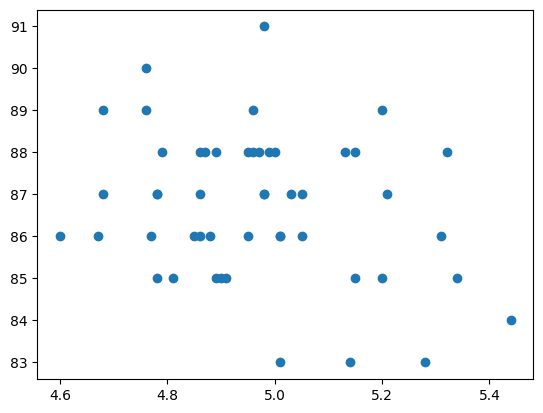

In [19]:
plt.scatter(x_0, y_0)

### Scatter plot of all clusters

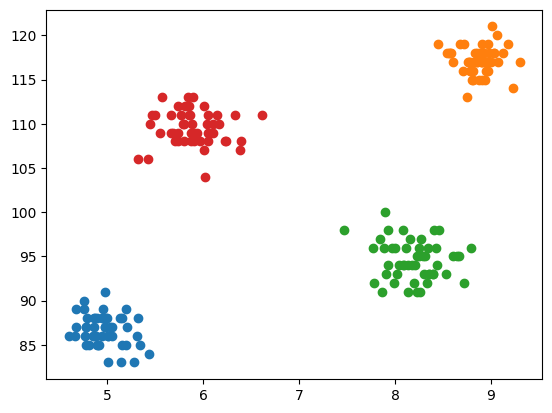

In [20]:
plt.scatter(X[y_means == 0, 0], X[y_means == 0, 1])
plt.scatter(X[y_means == 1, 0], X[y_means == 1, 1])
plt.scatter(X[y_means == 2, 0], X[y_means == 2, 1])
plt.scatter(X[y_means == 3, 0], X[y_means == 3, 1])

# Evaluation Metrics

## Theory

Both **Silhouette Score** and **Davies–Bouldin Index (DBI)** are **clustering evaluation metrics**. They help answer one question:

> **"Did my clustering algorithm create good clusters?"**

Imagine you don't know the correct labels (which is common in clustering). These metrics evaluate the quality of clusters based only on the data.


### 1. Silhouette Score


Imagine a classroom where students naturally form groups based on their interests.

Suppose:

* Football lovers sit together.
* Book lovers sit together.
* Music lovers sit together.

A student should:

* Sit **close to classmates in their own group** ✅
* Sit **far from students in other groups** ✅

This is exactly what the Silhouette Score measures.

Think of each student asking:

> "Am I sitting with my own friends, and am I far away from other groups?"

If yes → high score.

If not → low score.


### Simple Example

Suppose we have these points:

### Cluster A

```
(1,1)
(2,1)
(1,2)
```

### Cluster B

```
(8,8)
(9,8)
(8,9)
```

Visualization:

```
Cluster A          Cluster B

* *
 *

                     * *
                      *
```

These clusters are:

* compact
* well separated

Silhouette Score will be close to

```
1
```

Very good clustering.


#### Score Range

Silhouette ranges from

```
-1  to  1
```

#### Close to 1

Excellent clustering

```
0.9
0.8
0.7
```

Clusters are compact and separated.


#### Around 0

```
0.1
0.0
```

Clusters overlap.


### Negative

```
-0.2
-0.5
```

Many points are probably assigned to the wrong cluster.


<!-- ### Technical Definition

For each data point:

Calculate

#### a(i)

Average distance from the point to all other points **within its own cluster**.

This measures

> **Cluster cohesion**

Smaller is better.


Calculate

### b(i)

Average distance from the point to the **nearest neighboring cluster**.

This measures

> **Cluster separation**

Larger is better.


Silhouette formula

$$
s(i)=\frac{b(i)-a(i)}{\max(a(i),b(i))}
$$

Where

* (a(i)) = average intra-cluster distance
* (b(i)) = average nearest-cluster distance


Interpretation:

If

```
a = 2
b = 10
```

Point is much closer to its own cluster.

Excellent.


If

```
a = 6
b = 7
```

Point is almost equally close to another cluster.

Not good.


If

```
a = 8
b = 4
```

Point is closer to another cluster.

Wrong assignment.


The **overall Silhouette Score** is simply the average of all individual point scores.
 -->


### 2. Davies–Bouldin Index (DBI)

Now imagine each cluster is a family.

A good family should be:

* Members stay close together.
* Different families live far apart.

DBI asks:

> "How similar is one cluster to its most similar neighboring cluster?"

If two clusters look almost identical, that's bad.

If every cluster is clearly different, that's good.


#### Example

Good clustering

```
AAA

             BBB

                          CCC
```

Clusters are:

* compact
* far apart

DBI becomes

```
0.2
```

Very good.


#### Score Range

Unlike Silhouette,

DBI has **no fixed upper limit**.

Smaller is always better.

Examples

```
0.15 Excellent

0.40 Good

0.80 Acceptable

2.00 Poor

5.00 Very poor
```




### Visual Comparison

#### Good clustering

```
AAA

             BBB

                        CCC
```

Silhouette

```
0.92
```

High ✔

DBI

```
0.18
```

Low ✔


#### Quick Comparison Table

| Feature        | Silhouette Score                                  | Davies–Bouldin Index                            |
| -------------- | ------------------------------------------------- | ----------------------------------------------- |
| Goal           | Measures how well each point fits its own cluster | Measures how similar clusters are to each other |
| Good value     | High                                              | Low                                             |
| Best possible  | 1                                                 | 0                                               |
| Worst          | -1                                                | No upper limit                                  |
| Uses           | Point-to-cluster and nearest-cluster distances    | Cluster compactness and separation              |
| Interpretation | Higher means points are well assigned             | Lower means clusters are compact and distinct   |

## Rule of Thumb

* Use **Silhouette Score** when you want to understand **how well individual data points are assigned** to clusters. Higher is better.
* Use **Davies–Bouldin Index** when you want to compare **the overall compactness and separation of clusters**. Lower is better.
* In practice, it's common to compute **both metrics** when comparing clustering algorithms or choosing the number of clusters, because they provide complementary perspectives on clustering quality.


## Code Example

In [21]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score as sli, davies_bouldin_score as dbi
from sklearn.datasets import make_blobs

In [22]:
# Example dataset
X, _ = make_blobs(n_samples=500, centers=4, random_state=42)

In [23]:
X

array([[ -7.68905443,   6.62034649],
       [ -9.57651383,  -6.93440446],
       [  6.82968177,   1.1648714 ],
       [ -2.90130578,   7.55077118],
       [ -5.67841327,  -7.28818497],
       [ -6.04929137,  -7.73619342],
       [ -6.27824322,   7.22746302],
       [ -6.60917037,  -6.9303477 ],
       [  3.57225841,   1.8307902 ],
       [ -7.50444577,  -6.85401854],
       [  3.99330595,   0.89162168],
       [ -1.35060204,   8.19360381],
       [  6.77291221,   0.02108188],
       [ -1.93830711,  10.14985177],
       [ -6.58985233,  -4.80470879],
       [  5.69830332,   0.2144302 ],
       [ -2.58120774,  10.01781903],
       [ -9.96104978,   7.70593266],
       [ -8.75604377,   8.38900329],
       [ -3.6155326 ,   7.8180795 ],
       [  3.24131126,   2.53613892],
       [ -2.30033403,   7.054616  ],
       [  5.2164358 ,   2.28441984],
       [ -7.27280373,   7.25777265],
       [ -9.28476137,   7.51761291],
       [ -6.48517505,  -7.30109407],
       [ -7.13460441,  -5.3761166 ],
 

In [24]:
k_values = range(2,11)

sli_scores = []
db_scores = []

for k in k_values:
  kmeans = KMeans(n_clusters=k, n_init=10)
  labels = kmeans.fit_predict(X)

  sli_scores.append(sli(X, labels))
  db_scores.append(dbi(X, labels))



> **Note:** The `for` loop tests different values of **k** (e.g., from 2 to 10). For each value of **k**, `KMeans` is initialized with `n_init=10`, meaning the algorithm runs **10 times** using different initial centroid placements. After all 10 runs, the clustering with the **lowest inertia (within-cluster sum of squares)** is selected as the best solution. The Silhouette Score and Davies–Bouldin Index are then computed using this best clustering. This process reduces the risk of obtaining poor clusters due to unfavorable initial centroid selection.

Text(0.5, 1.0, 'Sil Score')

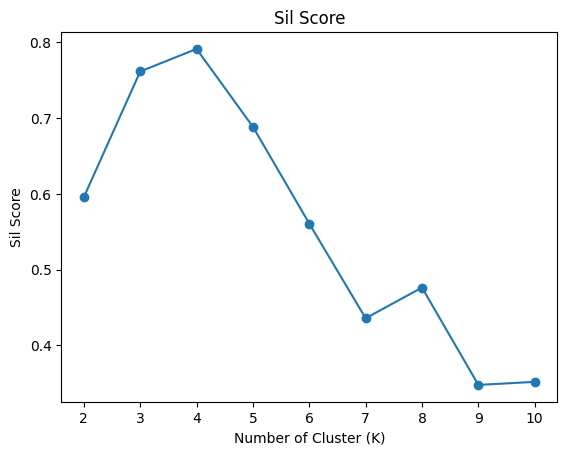

In [25]:
# Silhouette Score Plot

plt.plot(k_values, sli_scores, marker='o')
plt.xlabel('Number of Cluster (K)')
plt.ylabel("Sil Score")
plt.title("Sil Score")

Text(0.5, 1.0, 'DBI Score')

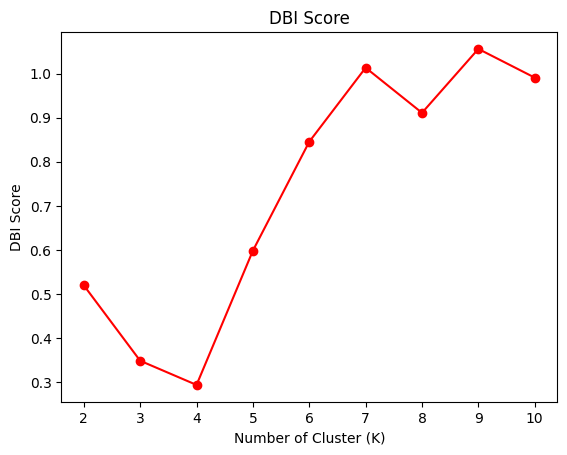

In [26]:
# Davies-Bouldin Index Plot

plt.plot(k_values, db_scores, marker='o', color='red')
plt.xlabel('Number of Cluster (K)')
plt.ylabel("DBI Score")
plt.title("DBI Score")

# KMeans 3D Data

### Create a example dataset using make_blobs

In [27]:
from sklearn.datasets import make_blobs

centroids = [(-5,-5,5),(5,5,-5),(3.5,-2.5,4),(-2.5,2.5,-4)]

cluster_std = [1,1,1,1]

X,y = make_blobs(n_samples=200,cluster_std=cluster_std,centers=centroids,n_features=3,random_state=1)

In [28]:
X

array([[ 4.33424548,  3.32580419, -4.17497018],
       [-3.32246719,  3.22171129, -4.625342  ],
       [-6.07296862, -4.13459237,  2.6984613 ],
       [ 6.90465871,  6.1110567 , -4.3409502 ],
       [-2.60839207,  2.95015551, -2.2346649 ],
       [ 5.88490881,  4.12271848, -5.86778722],
       [-4.68484061, -4.15383935,  4.14048406],
       [-1.82542929,  3.96089238, -3.4075272 ],
       [-5.34385368, -4.95640314,  4.37999916],
       [ 4.91549197,  4.70263812, -4.582698  ],
       [-3.80108212, -4.81484358,  4.62471505],
       [ 4.6735005 ,  3.65732421, -3.88561702],
       [-6.23005814, -4.4494625 ,  5.79280687],
       [-3.90232915,  2.95112294, -4.6949209 ],
       [ 3.72744124,  5.31354772, -4.49681519],
       [-3.3088472 ,  3.05743945, -3.81896126],
       [ 2.70273021, -2.21732429,  3.17390257],
       [ 4.06438286, -0.36217193,  3.214466  ],
       [ 4.69268607, -2.73794194,  5.15528789],
       [ 4.1210827 , -1.5438783 ,  3.29415949],
       [-6.61577235, -3.87858229,  5.408

### Visualize the data in 3d Scatter Plot

In [29]:
import plotly.express as px

fig = px.scatter_3d(x=X[:,0], y=X[:,1], z=X[:,2])
fig.show()

### Train the KMeans on 3D Data

In [30]:
# 20 Iterations -> range(1,21)
# init loop, init KMeans object with n_clusters=i, get prediction and append the intertia to wcss list

wcss = []

for i in range(1, 21):
  km = KMeans(n_clusters=i)
  km.fit_predict(X)
  wcss.append(km.inertia_)


In [31]:
wcss

[11143.784324503365,
 4122.40955760353,
 2163.269450436297,
 593.2516262404542,
 543.9531096775313,
 512.1346039517645,
 461.5200036314972,
 451.36359220117254,
 403.85554921071576,
 392.8135815652594,
 367.44113989042387,
 328.1827206383634,
 311.1938808958895,
 295.3954266526467,
 274.25751801248316,
 275.6217071590985,
 255.5531148582451,
 250.1922174308012,
 227.51537389793933,
 227.15457541006543]

### Visualize the Elbow Curve and Select Best K

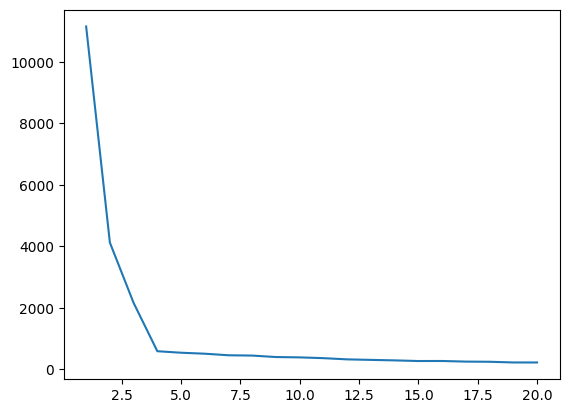

In [32]:
plt.plot(range(1,21), wcss)

### Retrain the Model with Best K Value

In [33]:
# Train
km = KMeans(n_clusters=4)

# km.fit_predict(X) -> y_pred
y_pred = km.fit_predict(X)

### Create the Data from of 3D data

In [34]:
df = pd.DataFrame()

df['col1'] = X[:, 0]
df['col2'] = X[:, 1]
df['col3'] = X[:, 2]
df['label'] = y_pred


In [35]:
df

,col1,col2,col3,label
0,4.334245,3.325804,-4.174970,0
1,-3.322467,3.221711,-4.625342,2
2,-6.072969,-4.134592,2.698461,1
3,6.904659,6.111057,-4.340950,0
4,-2.608392,2.950156,-2.234665,2
...,...,...,...,...
195,4.712692,5.680070,-5.319802,0
196,-4.137450,6.458603,-3.351356,2
197,-5.208894,-4.413377,5.838983,1
198,2.619422,-2.779098,5.622849,3


### Visualize 3D Clusters

In [36]:
fig = px.scatter_3d(df, x='col1', y='col2', z='col3', color='label')
fig.show()

In [37]:
# End of Notebook

# Agglomerative Clustering

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [39]:
customer_data = pd.read_csv('https://raw.githubusercontent.com/SagarChhabriya/data-science/refs/heads/main/datasets/TBD/shopping-data-clustering.csv')
customer_data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [40]:
# We are going to use only income and spending score
data = customer_data.iloc[:, 3:5].values

In [41]:
data

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

Let us first create the dendogram to estimate/identify cluster count.

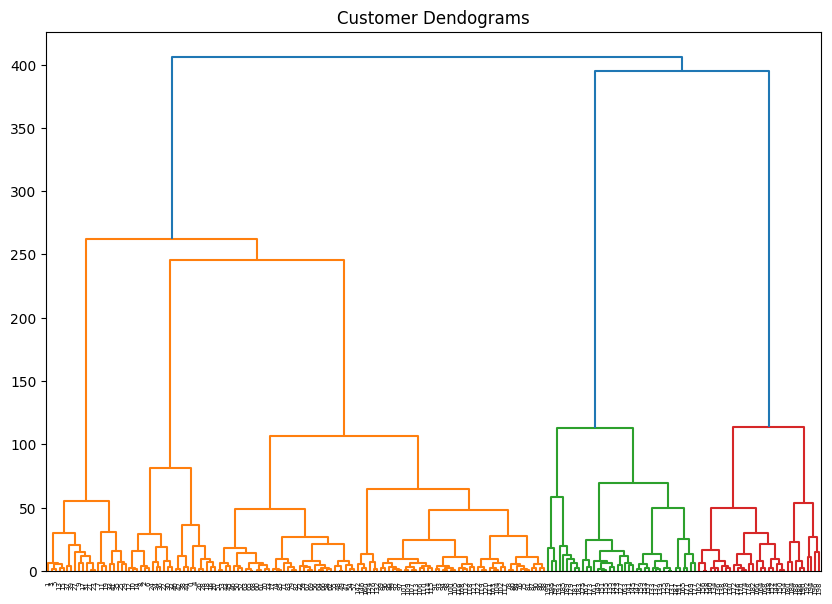

In [42]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10, 7))

plt.title("Customer Dendograms")

dend = shc.dendrogram(shc.linkage(data, method='ward'))

Train the model

In [43]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_pred = cluster.fit_predict(data)

In [44]:
y_pred

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

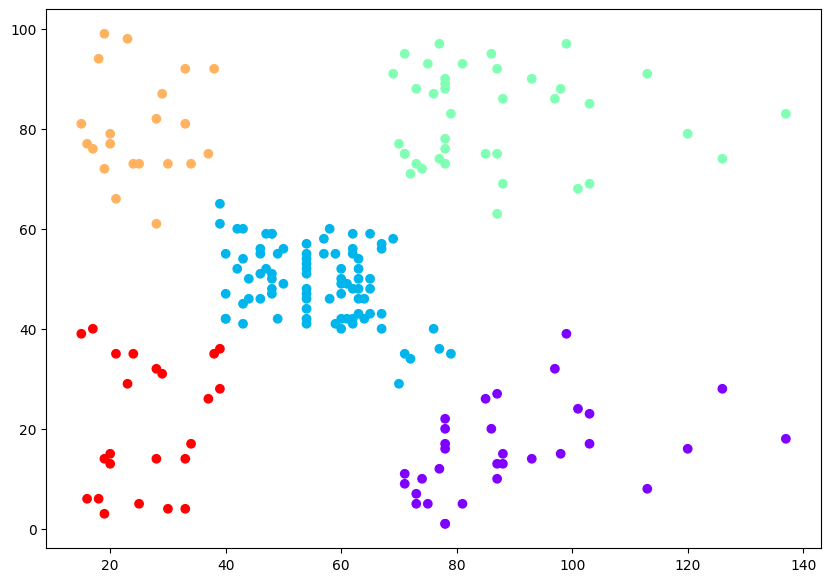

In [45]:
plt.figure(figsize=(10, 7))
plt.scatter(data[:,0], data[:,1], c=cluster.labels_, cmap='rainbow')